In [1]:
import subprocess
subprocess.run(["pip", "install", "mne", "pyEDFlib", "scipy", "numpy", "torch", "--quiet"])

import os
import mne
import numpy as np
import scipy.signal as signal

mne.set_log_level("ERROR")

print("mne version:", mne.__version__)
print("numpy version:", np.__version__)
print("All libraries loaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 29.2 MB/s eta 0:00:00
mne version: 1.11.0
numpy version: 2.0.2
All libraries loaded


In [2]:
SHHS1_EDF = "/kaggle/input/datasets/ankit20554/shhs1-dataset/SHHS1/EDF"
SHHS1_XML = "/kaggle/input/datasets/ankit20554/shhs1-dataset/SHHS1/XML"

SHHS2_EDF = "/kaggle/input/datasets/ankit20554/validation-dataset-shhs2/SHHS2/EDF"
SHHS2_XML = "/kaggle/input/datasets/ankit20554/validation-dataset-shhs2/SHHS2/XML"

OUT_SHHS1 = "/kaggle/working/processed_shhs1/"
OUT_SHHS2 = "/kaggle/working/processed_shhs2/"

os.makedirs(OUT_SHHS1, exist_ok=True)
os.makedirs(OUT_SHHS2, exist_ok=True)

shhs1_edfs = sorted([f for f in os.listdir(SHHS1_EDF) if f.endswith(".edf")])
shhs1_xmls = sorted([f for f in os.listdir(SHHS1_XML) if f.endswith(".xml")])

shhs2_edfs = sorted([f for f in os.listdir(SHHS2_EDF) if f.endswith(".edf")])
shhs2_xmls = sorted([f for f in os.listdir(SHHS2_XML) if f.endswith(".xml")])

print("SHHS1 EDF count:", len(shhs1_edfs))
print("SHHS1 XML count:", len(shhs1_xmls))
print("SHHS2 EDF count:", len(shhs2_edfs))
print("SHHS2 XML count:", len(shhs2_xmls))

print("First SHHS1 EDF:", shhs1_edfs[0])
print("First SHHS1 XML:", shhs1_xmls[0])
print("First SHHS2 EDF:", shhs2_edfs[0])
print("First SHHS2 XML:", shhs2_xmls[0])

SHHS1 EDF count: 100
SHHS1 XML count: 100
SHHS2 EDF count: 52
SHHS2 XML count: 52
First SHHS1 EDF: shhs1-200001.edf
First SHHS1 XML: shhs1-200001-nsrr.xml
First SHHS2 EDF: shhs2-200077.edf
First SHHS2 XML: shhs2-200077-nsrr.xml


In [3]:
EEG_PRIMARY = "EEG"
EEG_FALLBACK = "EEG(sec)"
EOG_LEFT = "EOG(L)"
EOG_RIGHT = "EOG(R)"
SFREQ = 125
EPOCH_SAMPLES = 3000
SEGMENT_SIZE = 300
N_SEGMENTS = 10

def load_edf_channels(edf_path):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    ch_names = raw.ch_names
    sfreq = raw.info["sfreq"]

    print("File:", os.path.basename(edf_path))
    print("Original sampling rate:", sfreq)

    if sfreq != 125.0:
        print("Resampling from", sfreq, "Hz to 125 Hz")
        raw.resample(125.0, verbose=False)
        sfreq = 125.0
        print("Resampled to 125 Hz")
    else:
        print("Sampling rate is already 125 Hz")

    print("Channels found:", ch_names)

    if EEG_PRIMARY in ch_names:
        eeg_ch = EEG_PRIMARY
        print("EEG selected:", EEG_PRIMARY)
    elif EEG_FALLBACK in ch_names:
        eeg_ch = EEG_FALLBACK
        print("EEG fallback selected:", EEG_FALLBACK)
    else:
        print("ERROR: No EEG channel found in", edf_path)
        return None, None

    if EOG_LEFT not in ch_names and EOG_RIGHT not in ch_names:
        print("ERROR: Both EOG channels missing in", edf_path)
        return None, None

    eeg_data = raw.get_data(picks=[eeg_ch])[0]

    if EOG_LEFT in ch_names:
        eog_l = raw.get_data(picks=[EOG_LEFT])[0]
    else:
        print("WARNING: EOG(L) missing, filling with zeros")
        eog_l = np.zeros_like(eeg_data)

    if EOG_RIGHT in ch_names:
        eog_r = raw.get_data(picks=[EOG_RIGHT])[0]
    else:
        print("WARNING: EOG(R) missing, filling with zeros")
        eog_r = np.zeros_like(eeg_data)

    signals = np.stack([eeg_data, eog_l, eog_r], axis=0)
    print("Raw signal shape (3, total_samples):", signals.shape)

    return signals, sfreq

test_edf = os.path.join(SHHS1_EDF, shhs1_edfs[0])
signals, sfreq = load_edf_channels(test_edf)

File: shhs1-200001.edf
Original sampling rate: 125.0
Sampling rate is already 125 Hz
Channels found: ['SaO2', 'H.R.', 'EEG(sec)', 'ECG', 'EMG', 'EOG(L)', 'EOG(R)', 'EEG', 'THOR RES', 'ABDO RES', 'POSITION', 'LIGHT', 'NEW AIR', 'OX stat']
EEG selected: EEG
Raw signal shape (3, total_samples): (3, 4065000)


In [4]:
import xml.etree.ElementTree as ET

STAGE_MAP = {
    "Wake":    0,
    "Stage 1": 1,
    "Stage 2": 1,
    "Stage 3": 1,
    "Stage 4": 1,
    "REM":     2,
}

def load_xml_labels(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    epochs = []

    for event in root.iter("ScoredEvent"):
        event_type = event.findtext("EventType")
        if event_type != "Stages|Stages":
            continue

        stage_str = event.findtext("EventConcept")
        start_str = event.findtext("Start")
        duration_str = event.findtext("Duration")

        if stage_str is None or start_str is None or duration_str is None:
            continue

        start = float(start_str)
        duration = float(duration_str)
        n_epochs = int(round(duration / 30.0))

        mapped = None
        for key in STAGE_MAP:
            if key.lower() in stage_str.lower():
                mapped = STAGE_MAP[key]
                break

        if mapped is None:
            continue

        for i in range(n_epochs):
            epochs.append(mapped)

    labels = np.array(epochs, dtype=np.int64)
    print("File:", os.path.basename(xml_path))
    print("Total epochs parsed:", len(labels))
    print("Wake epochs:", np.sum(labels == 0))
    print("NREM epochs:", np.sum(labels == 1))
    print("REM  epochs:", np.sum(labels == 2))

    return labels

test_xml = os.path.join(SHHS1_XML, shhs1_xmls[0])
labels = load_xml_labels(test_xml)

File: shhs1-200001-nsrr.xml
Total epochs parsed: 1084
Wake epochs: 333
NREM epochs: 649
REM  epochs: 102


## Cell 5: Bandpass Filter (0.5 - 45 Hz)

We apply a 4th order Butterworth bandpass filter to all
3 channels independently.

Frequency range: 0.5 Hz to 45 Hz
- Removes slow drift below 0.5 Hz
- Removes high frequency noise above 45 Hz
- Preserves clinically relevant EEG and EOG frequencies

In [5]:
def bandpass_filter(signals, lowcut=0.5, highcut=45.0, fs=125.0, order=4):
    nyq = fs / 2.0
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype="band")
    filtered = np.zeros_like(signals)
    for i in range(signals.shape[0]):
        filtered[i] = signal.filtfilt(b, a, signals[i])
    return filtered

filtered_signals = bandpass_filter(signals, fs=SFREQ)

print("Input shape:", signals.shape)
print("Filtered shape:", filtered_signals.shape)
print("EEG raw mean:", round(float(np.mean(signals[0])), 6))
print("EEG filtered mean:", round(float(np.mean(filtered_signals[0])), 6))
print("EEG raw std:", round(float(np.std(signals[0])), 6))
print("EEG filtered std:", round(float(np.std(filtered_signals[0])), 6))

Input shape: (3, 4065000)
Filtered shape: (3, 4065000)
EEG raw mean: -1e-06
EEG filtered mean: -0.0
EEG raw std: 3.7e-05
EEG filtered std: 3.2e-05


## Cell 6: Epoch, Normalize and Reshape

For each 30-second epoch:
1. Extract 3750 samples (30 sec × 125 Hz)
2. Crop to 3000 samples (removes last 6 seconds)
3. Apply z-score normalization per channel
4. Reshape to (10, 3, 300)
   - 10 segments per epoch
   - 3 channels
   - 300 samples per segment

Final X shape per subject: (num_epochs, 10, 3, 300)
Final y shape per subject: (num_epochs,)

In [6]:
def epoch_normalize_reshape(filtered_signals, labels, fs=125, epoch_sec=30, crop=3000, n_seg=10, seg_size=300):
    epoch_samples = fs * epoch_sec
    total_samples = filtered_signals.shape[1]
    n_channels = filtered_signals.shape[0]

    total_possible_epochs = total_samples // epoch_samples
    usable_epochs = min(total_possible_epochs, len(labels))

    print("Total possible epochs from signal:", total_possible_epochs)
    print("Total epochs from XML:", len(labels))
    print("Usable epochs (min of both):", usable_epochs)

    X_list = []
    y_list = []

    for i in range(usable_epochs):
        start = i * epoch_samples
        end = start + epoch_samples
        epoch = filtered_signals[:, start:end]

        epoch = epoch[:, :crop]

        for ch in range(n_channels):
            mean = np.mean(epoch[ch])
            std = np.std(epoch[ch])
            if std < 1e-10:
                epoch[ch] = np.zeros_like(epoch[ch])
            else:
                epoch[ch] = (epoch[ch] - mean) / std

        epoch = epoch.reshape(n_channels, n_seg, seg_size)
        epoch = epoch.transpose(1, 0, 2)

        X_list.append(epoch)
        y_list.append(labels[i])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)

    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("y unique classes:", np.unique(y))
    print("Sample X[0] mean:", round(float(np.mean(X[0])), 4))
    print("Sample X[0] std:", round(float(np.std(X[0])), 4))

    return X, y

X, y = epoch_normalize_reshape(filtered_signals, labels)

Total possible epochs from signal: 1084
Total epochs from XML: 1084
Usable epochs (min of both): 1084
X shape: (1084, 10, 3, 300)
y shape: (1084,)
y unique classes: [0 1 2]
Sample X[0] mean: -0.0
Sample X[0] std: 1.0


## Cell 7: SHHS1 Subject-wise Preprocessing Loop

We preprocess all 100 SHHS1 subjects one by one.
For each subject:
1. Load EDF → extract channels
2. Load XML → extract labels
3. Filter → epoch → normalize → reshape
4. Save X and y as .npy files

If a subject is already processed, we skip them.
This makes the loop resumable without reprocessing.

Output: 200 files (100 X.npy + 100 y.npy) in processed_shhs1/

In [7]:
def get_subject_id(filename):
    return filename.replace(".edf", "").replace("-nsrr.xml", "").replace(".xml", "")

def preprocess_subject(edf_path, xml_path, out_dir):
    subject_id = get_subject_id(os.path.basename(edf_path))
    out_X = os.path.join(out_dir, subject_id + "_X.npy")
    out_y = os.path.join(out_dir, subject_id + "_y.npy")

    if os.path.exists(out_X) and os.path.exists(out_y):
        print(subject_id, "already processed, skipping")
        return

    signals, sfreq = load_edf_channels(edf_path)
    if signals is None:
        print("SKIP:", subject_id, "- channel load failed")
        return

    labels = load_xml_labels(xml_path)
    if len(labels) == 0:
        print("SKIP:", subject_id, "- no labels found")
        return

    filtered = bandpass_filter(signals, fs=SFREQ)
    X, y = epoch_normalize_reshape(filtered, labels)

    if X.shape[0] == 0:
        print("SKIP:", subject_id, "- no usable epochs")
        return

    np.save(out_X, X)
    np.save(out_y, y)
    print("SAVED:", subject_id, "| X:", X.shape, "| y:", y.shape)

    del signals, filtered, X, y

print("Starting SHHS1 preprocessing...")
print("Total subjects:", len(shhs1_edfs))
print()

skipped = 0
processed = 0

for i, edf_file in enumerate(shhs1_edfs):
    subject_id = get_subject_id(edf_file)
    xml_file = subject_id + "-nsrr.xml"
    xml_path = os.path.join(SHHS1_XML, xml_file)
    edf_path = os.path.join(SHHS1_EDF, edf_file)

    if not os.path.exists(xml_path):
        print("SKIP:", subject_id, "- XML not found")
        skipped += 1
        continue

    print(f"[{i+1}/100] Processing {subject_id}")
    preprocess_subject(edf_path, xml_path, OUT_SHHS1)
    processed += 1

print()
print("SHHS1 preprocessing done")
print("Processed:", processed)
print("Skipped:", skipped)
print("Files in output:", len(os.listdir(OUT_SHHS1)))

Starting SHHS1 preprocessing...
Total subjects: 100

[1/100] Processing shhs1-200001
File: shhs1-200001.edf
Original sampling rate: 125.0
Sampling rate is already 125 Hz
Channels found: ['SaO2', 'H.R.', 'EEG(sec)', 'ECG', 'EMG', 'EOG(L)', 'EOG(R)', 'EEG', 'THOR RES', 'ABDO RES', 'POSITION', 'LIGHT', 'NEW AIR', 'OX stat']
EEG selected: EEG
Raw signal shape (3, total_samples): (3, 4065000)
File: shhs1-200001-nsrr.xml
Total epochs parsed: 1084
Wake epochs: 333
NREM epochs: 649
REM  epochs: 102
Total possible epochs from signal: 1084
Total epochs from XML: 1084
Usable epochs (min of both): 1084
X shape: (1084, 10, 3, 300)
y shape: (1084,)
y unique classes: [0 1 2]
Sample X[0] mean: -0.0
Sample X[0] std: 1.0
SAVED: shhs1-200001 | X: (1084, 10, 3, 300) | y: (1084,)
[2/100] Processing shhs1-200002
File: shhs1-200002.edf
Original sampling rate: 125.0
Sampling rate is already 125 Hz
Channels found: ['SaO2', 'H.R.', 'EEG(sec)', 'ECG', 'EMG', 'EOG(L)', 'EOG(R)', 'EEG', 'THOR RES', 'ABDO RES', 'PO

## Cell 8: SHHS2 Subject-wise Preprocessing Loop

Same pipeline as Cell 7 but for 52 SHHS2 subjects.

SHHS2 files have different sampling rates (250 Hz or 256 Hz).
We resample all of them to 125 Hz before processing so
every epoch represents the same 24 seconds of real signal.

Output: 104 files (52 X.npy + 52 y.npy) in processed_shhs2/

In [8]:
import shutil

shutil.rmtree(OUT_SHHS2)
os.makedirs(OUT_SHHS2, exist_ok=True)
print("Old SHHS2 files deleted")
print("Files remaining:", len(os.listdir(OUT_SHHS2)))
print()

print("Starting SHHS2 preprocessing with resampling fix...")
print("Total subjects:", len(shhs2_edfs))
print()

skipped = 0
processed = 0

for i, edf_file in enumerate(shhs2_edfs):
    subject_id = get_subject_id(edf_file)
    xml_file = subject_id + "-nsrr.xml"
    xml_path = os.path.join(SHHS2_XML, xml_file)
    edf_path = os.path.join(SHHS2_EDF, edf_file)

    if not os.path.exists(xml_path):
        print("SKIP:", subject_id, "- XML not found")
        skipped += 1
        continue

    print(f"[{i+1}/52] Processing {subject_id}")
    preprocess_subject(edf_path, xml_path, OUT_SHHS2)
    processed += 1

print()
print("SHHS2 preprocessing done")
print("Processed:", processed)
print("Skipped:", skipped)
print("Files in output:", len(os.listdir(OUT_SHHS2)))

Old SHHS2 files deleted
Files remaining: 0

Starting SHHS2 preprocessing with resampling fix...
Total subjects: 52

[1/52] Processing shhs2-200077
File: shhs2-200077.edf
Original sampling rate: 256.0
Resampling from 256.0 Hz to 125 Hz
Resampled to 125 Hz
Channels found: ['SaO2', 'PR', 'EEG(sec)', 'ECG', 'EMG', 'EOG(L)', 'EOG(R)', 'EEG', 'AIRFLOW', 'THOR RES', 'ABDO RES', 'POSITION', 'LIGHT', 'OX STAT']
EEG selected: EEG
Raw signal shape (3, total_samples): (3, 5786250)
File: shhs2-200077-nsrr.xml
Total epochs parsed: 1543
Wake epochs: 777
NREM epochs: 592
REM  epochs: 174
Total possible epochs from signal: 1543
Total epochs from XML: 1543
Usable epochs (min of both): 1543
X shape: (1543, 10, 3, 300)
y shape: (1543,)
y unique classes: [0 1 2]
Sample X[0] mean: 0.0
Sample X[0] std: 1.0
SAVED: shhs2-200077 | X: (1543, 10, 3, 300) | y: (1543,)
[2/52] Processing shhs2-200078
File: shhs2-200078.edf
Original sampling rate: 250.0
Resampling from 250.0 Hz to 125 Hz
Resampled to 125 Hz
Channels 

## Cell 9: Verify All Saved .npy Files

We verify that all files are saved correctly by:
1. Counting X and y files for both SHHS1 and SHHS2
2. Counting total epochs across all subjects
3. Checking shape and unique classes of a sample file

Expected:
- SHHS1: 100 X files, 100 y files, ~98985 total epochs
- SHHS2: 52 X files, 52 y files, ~66853 total epochs

In [9]:
shhs1_files = sorted(os.listdir(OUT_SHHS1))
shhs2_files = sorted(os.listdir(OUT_SHHS2))

shhs1_X_files = [f for f in shhs1_files if f.endswith("_X.npy")]
shhs1_y_files = [f for f in shhs1_files if f.endswith("_y.npy")]
shhs2_X_files = [f for f in shhs2_files if f.endswith("_X.npy")]
shhs2_y_files = [f for f in shhs2_files if f.endswith("_y.npy")]

print("SHHS1 X files:", len(shhs1_X_files))
print("SHHS1 y files:", len(shhs1_y_files))
print("SHHS2 X files:", len(shhs2_X_files))
print("SHHS2 y files:", len(shhs2_y_files))

total_train_epochs = 0
total_val_epochs = 0

for f in shhs1_X_files:
    X = np.load(os.path.join(OUT_SHHS1, f))
    total_train_epochs += X.shape[0]

for f in shhs2_X_files:
    X = np.load(os.path.join(OUT_SHHS2, f))
    total_val_epochs += X.shape[0]

print()
print("Total SHHS1 training epochs:", total_train_epochs)
print("Total SHHS2 validation epochs:", total_val_epochs)

sample_X = np.load(os.path.join(OUT_SHHS1, shhs1_X_files[0]))
sample_y = np.load(os.path.join(OUT_SHHS1, shhs1_y_files[0]))
print()
print("Sample SHHS1 X shape:", sample_X.shape)
print("Sample SHHS1 y shape:", sample_y.shape)
print("Sample SHHS1 y unique:", np.unique(sample_y))

SHHS1 X files: 100
SHHS1 y files: 100
SHHS2 X files: 52
SHHS2 y files: 52

Total SHHS1 training epochs: 98985
Total SHHS2 validation epochs: 66853

Sample SHHS1 X shape: (1084, 10, 3, 300)
Sample SHHS1 y shape: (1084,)
Sample SHHS1 y unique: [0 1 2]


## Cell 10: PyTorch Dataset Class

We build a custom PyTorch Dataset that:
1. Loads all .npy files from the processed folder
2. Concatenates them into one large array
3. Returns (X, y) pairs for each epoch

This dataset is used by the DataLoader for batched training.

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader

class SleepDataset(Dataset):
    def __init__(self, data_dir):
        self.samples = []
        self.labels = []

        X_files = sorted([f for f in os.listdir(data_dir) if f.endswith("_X.npy")])

        print("Loading dataset from:", data_dir)
        print("Total subjects:", len(X_files))

        for f in X_files:
            subject_id = f.replace("_X.npy", "")
            X_path = os.path.join(data_dir, f)
            y_path = os.path.join(data_dir, subject_id + "_y.npy")

            if not os.path.exists(y_path):
                print("SKIP:", subject_id, "- y file missing")
                continue

            X = np.load(X_path)
            y = np.load(y_path)

            self.samples.append(X)
            self.labels.append(y)

        self.samples = np.concatenate(self.samples, axis=0).astype(np.float32)
        self.labels = np.concatenate(self.labels, axis=0).astype(np.int64)

        print("Total epochs loaded:", self.samples.shape[0])
        print("X shape:", self.samples.shape)
        print("y shape:", self.labels.shape)
        print("Class distribution:")
        for cls, name in zip([0, 1, 2], ["Wake", "NREM", "REM"]):
            count = np.sum(self.labels == cls)
            pct = 100 * count / len(self.labels)
            print(f"  {name}: {count} ({pct:.1f}%)")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        X = torch.tensor(self.samples[idx])
        y = torch.tensor(self.labels[idx])
        return X, y

print("Building SHHS1 training dataset...")
train_dataset = SleepDataset(OUT_SHHS1)
print()
print("Building SHHS2 validation dataset...")
val_dataset = SleepDataset(OUT_SHHS2)

Building SHHS1 training dataset...
Loading dataset from: /kaggle/working/processed_shhs1/
Total subjects: 100
Total epochs loaded: 98985
X shape: (98985, 10, 3, 300)
y shape: (98985,)
Class distribution:
  Wake: 32161 (32.5%)
  NREM: 54968 (55.5%)
  REM: 11856 (12.0%)

Building SHHS2 validation dataset...
Loading dataset from: /kaggle/working/processed_shhs2/
Total subjects: 52
Total epochs loaded: 66853
X shape: (66853, 10, 3, 300)
y shape: (66853,)
Class distribution:
  Wake: 27742 (41.5%)
  NREM: 30387 (45.5%)
  REM: 8724 (13.0%)


## Cell 11: DataLoader with Balanced Sampling

We address class imbalance using two techniques:
1. Class weights → penalize mistakes on rare classes (REM)
2. WeightedRandomSampler → each batch has balanced classes

Class weights:
- Wake: 1.03
- NREM: 0.60
- REM:  2.78

This ensures the model learns all 3 sleep stages equally.

In [11]:
from torch.utils.data import DataLoader, WeightedRandomSampler

BATCH_SIZE = 64

label_counts = np.bincount(train_dataset.labels, minlength=3)
total = label_counts.sum()
class_weights = total / (3.0 * label_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

print("Label counts:", label_counts)
print("Class weights:", class_weights)

sample_weights = np.array([class_weights[label].item() for label in train_dataset.labels])
sample_weights = torch.tensor(sample_weights, dtype=torch.float32)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print()
print("Batch size:", BATCH_SIZE)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

X_batch, y_batch = next(iter(train_loader))
unique, counts = torch.unique(y_batch, return_counts=True)
print()
print("Sample batch X shape:", X_batch.shape)
print("Sample batch y shape:", y_batch.shape)
print("Batch class distribution:")
for u, c in zip(unique.tolist(), counts.tolist()):
    name = ["Wake", "NREM", "REM"][u]
    print(f"  {name}: {c}")

Label counts: [32161 54968 11856]
Class weights: tensor([1.0259, 0.6003, 2.7830])

Batch size: 64
Train batches: 1547
Val batches: 1045

Sample batch X shape: torch.Size([64, 10, 3, 300])
Sample batch y shape: torch.Size([64])
Batch class distribution:
  Wake: 23
  NREM: 22
  REM: 19


## Cell 12: Temporal Convolutional Network (TCN) Model

We build a two-level TCN architecture:

Level 1 - Segment Encoder:
- Processes each of the 10 segments independently
- 3 TemporalBlocks with increasing dilation (1, 2, 4)
- Channels: 3 → 32 → 64 → 128

Level 2 - Epoch TCN:
- Combines segment features across time
- 2 TemporalBlocks with dilation (1, 2)

Classifier:
- Linear(128, 64) → ReLU → Dropout → Linear(64, 3)

Total parameters: 314,019
Input shape:  (batch, 10, 3, 300)
Output shape: (batch, 3)

In [12]:
import torch.nn as nn

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super(TemporalBlock, self).__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               dilation=dilation, padding=padding)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               dilation=dilation, padding=padding)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.norm1 = nn.BatchNorm1d(out_channels)
        self.norm2 = nn.BatchNorm1d(out_channels)
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None

    def forward(self, x):
        out = self.conv1(x)
        out = out[:, :, :x.shape[2]]
        out = self.norm1(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = out[:, :, :x.shape[2]]
        out = self.norm2(out)
        out = self.relu(out)
        out = self.dropout(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class SleepTCN(nn.Module):
    def __init__(self, in_channels=3, num_classes=3):
        super(SleepTCN, self).__init__()

        self.segment_encoder = nn.Sequential(
            TemporalBlock(in_channels, 32, kernel_size=3, dilation=1),
            TemporalBlock(32, 64, kernel_size=3, dilation=2),
            TemporalBlock(64, 128, kernel_size=3, dilation=4),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.epoch_tcn = nn.Sequential(
            TemporalBlock(128, 128, kernel_size=3, dilation=1),
            TemporalBlock(128, 128, kernel_size=3, dilation=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        batch_size, n_segments, n_channels, seg_len = x.shape

        x = x.view(batch_size * n_segments, n_channels, seg_len)
        x = self.segment_encoder(x)
        x = self.pool(x).squeeze(-1)

        x = x.view(batch_size, n_segments, -1)
        x = x.permute(0, 2, 1)
        x = self.epoch_tcn(x)
        x = x.mean(dim=2)

        out = self.classifier(x)
        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = SleepTCN(in_channels=3, num_classes=3).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

dummy = torch.randn(4, 10, 3, 300).to(device)
out = model(dummy)
print("Dummy input shape:", dummy.shape)
print("Dummy output shape:", out.shape)

Device: cuda
Total parameters: 314019
Trainable parameters: 314019
Dummy input shape: torch.Size([4, 10, 3, 300])
Dummy output shape: torch.Size([4, 3])


In [13]:
import torch.optim as optim
from sklearn.metrics import accuracy_score

EPOCHS = 50
LEARNING_RATE = 0.001
PATIENCE = 10
BEST_MODEL_PATH = "/kaggle/working/best_model.pth"

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_val_loss = float("inf")
patience_counter = 0
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

print("Starting training...")
print(f"Epochs: {EPOCHS} | LR: {LEARNING_RATE} | Patience: {PATIENCE} | Batch: {BATCH_SIZE}")
print()

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    train_preds = []
    train_targets = []

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        train_preds.extend(preds)
        train_targets.extend(y_batch.cpu().numpy())

    model.eval()
    val_losses = []
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_losses.append(loss.item())
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_targets.extend(y_batch.cpu().numpy())

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)
    train_acc = accuracy_score(train_targets, train_preds)
    val_acc = accuracy_score(val_targets, val_preds)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  Best model saved at epoch {epoch}")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print()
        print(f"Early stopping triggered at epoch {epoch}")
        break

print()
print("Training complete")
print("Best validation loss:", round(best_val_loss, 4))

Starting training...
Epochs: 50 | LR: 0.001 | Patience: 10 | Batch: 64

Epoch 01/50 | Train Loss: 0.3687 | Val Loss: 0.4212 | Train Acc: 0.7908 | Val Acc: 0.8610
  Best model saved at epoch 1
Epoch 02/50 | Train Loss: 0.2854 | Val Loss: 0.4886 | Train Acc: 0.8411 | Val Acc: 0.8196
  No improvement. Patience: 1/10
Epoch 03/50 | Train Loss: 0.2571 | Val Loss: 0.4680 | Train Acc: 0.8551 | Val Acc: 0.8409
  No improvement. Patience: 2/10
Epoch 04/50 | Train Loss: 0.2322 | Val Loss: 0.4799 | Train Acc: 0.8690 | Val Acc: 0.8344
  No improvement. Patience: 3/10
Epoch 05/50 | Train Loss: 0.2182 | Val Loss: 0.4514 | Train Acc: 0.8765 | Val Acc: 0.8347
  No improvement. Patience: 4/10
Epoch 06/50 | Train Loss: 0.2053 | Val Loss: 0.3535 | Train Acc: 0.8829 | Val Acc: 0.8702
  Best model saved at epoch 6
Epoch 07/50 | Train Loss: 0.1935 | Val Loss: 0.4316 | Train Acc: 0.8898 | Val Acc: 0.8522
  No improvement. Patience: 1/10
Epoch 08/50 | Train Loss: 0.1863 | Val Loss: 0.4727 | Train Acc: 0.8943 |

Best model loaded from: /kaggle/working/best_model.pth

Classification Report:
              precision    recall  f1-score   support

        Wake       0.95      0.88      0.91     27742
        NREM       0.91      0.88      0.90     30387
         REM       0.60      0.82      0.70      8724

    accuracy                           0.87     66853
   macro avg       0.82      0.86      0.83     66853
weighted avg       0.89      0.87      0.88     66853



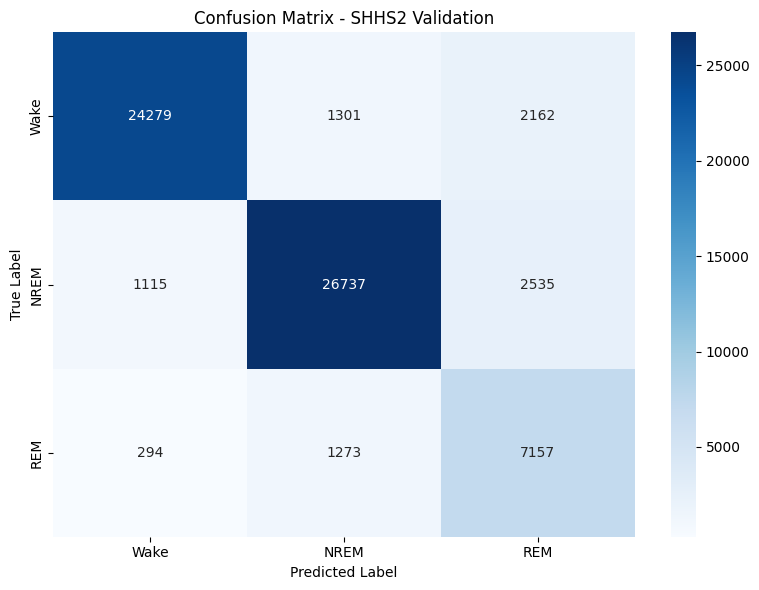

Confusion matrix saved


In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()
print("Best model loaded from:", BEST_MODEL_PATH)
print()

all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=["Wake", "NREM", "REM"]))

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Wake", "NREM", "REM"],
            yticklabels=["Wake", "NREM", "REM"])
plt.title("Confusion Matrix - SHHS2 Validation")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved")

## Cell 15: Run Model on 3 Unseen SHHS2 Subjects

We demonstrate the complete pipeline on 3 individual
SHHS2 subjects that were never seen during training.

For each subject we:
1. Load raw EDF file
2. Preprocess (resample, filter, epoch, normalize)
3. Run through trained TCN model
4. Get epoch-by-epoch sleep stage predictions

Subjects chosen to show variety:
- shhs2-200179 → moderate sleeper
- shhs2-200153 → very poor sleeper
- shhs2-200088 → fair sleeper

In [15]:
def predict_subject(edf_path, xml_path):
    subject_id = get_subject_id(os.path.basename(edf_path))
    print("Processing subject:", subject_id)

    signals, sfreq = load_edf_channels(edf_path)
    if signals is None:
        print("SKIP: channel load failed")
        return None, None, None

    labels = load_xml_labels(xml_path)
    filtered = bandpass_filter(signals, fs=SFREQ)
    X, y_true = epoch_normalize_reshape(filtered, labels)

    X_tensor = torch.tensor(X, dtype=torch.float32)
    dataset = torch.utils.data.TensorDataset(X_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)

    model.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            out = model(batch[0].to(device))
            p = torch.argmax(out, dim=1).cpu().numpy()
            preds.extend(p)

    preds = np.array(preds)
    y_true = np.array(y_true)

    acc = np.mean(preds == y_true)
    print("Subject accuracy:", round(acc * 100, 2), "%")
    print("True  distribution → Wake:", np.sum(y_true==0), "NREM:", np.sum(y_true==1), "REM:", np.sum(y_true==2))
    print("Pred  distribution → Wake:", np.sum(preds==0), "NREM:", np.sum(preds==1), "REM:", np.sum(preds==2))

    return preds, y_true, subject_id

demo_subjects = [
    ("shhs2-200179.edf", "shhs2-200179-nsrr.xml"),
    ("shhs2-200153.edf", "shhs2-200153-nsrr.xml"),
    ("shhs2-200088.edf", "shhs2-200088-nsrr.xml"),
]

results = {}

for edf_file, xml_file in demo_subjects:
    edf_path = os.path.join(SHHS2_EDF, edf_file)
    xml_path = os.path.join(SHHS2_XML, xml_file)
    print()
    print("="*50)
    preds, y_true, subject_id = predict_subject(edf_path, xml_path)
    if preds is not None:
        results[subject_id] = {"preds": preds, "y_true": y_true}
    print("="*50)

print()
print("Done. Subjects processed:", list(results.keys()))


Processing subject: shhs2-200179
File: shhs2-200179.edf
Original sampling rate: 250.0
Resampling from 250.0 Hz to 125 Hz
Resampled to 125 Hz
Channels found: ['SaO2', 'PR', 'EEG(sec)', 'ECG', 'EMG', 'EOG(L)', 'EOG(R)', 'EEG', 'AIRFLOW', 'THOR RES', 'ABDO RES', 'POSITION', 'LIGHT', 'OX STAT']
EEG selected: EEG
Raw signal shape (3, total_samples): (3, 4860000)
File: shhs2-200179-nsrr.xml
Total epochs parsed: 1296
Wake epochs: 595
NREM epochs: 526
REM  epochs: 175
Total possible epochs from signal: 1296
Total epochs from XML: 1296
Usable epochs (min of both): 1296
X shape: (1296, 10, 3, 300)
y shape: (1296,)
y unique classes: [0 1 2]
Sample X[0] mean: 0.0
Sample X[0] std: 1.0
Subject accuracy: 71.91 %
True  distribution → Wake: 595 NREM: 526 REM: 175
Pred  distribution → Wake: 268 NREM: 606 REM: 422

Processing subject: shhs2-200153
File: shhs2-200153.edf
Original sampling rate: 256.0
Resampling from 256.0 Hz to 125 Hz
Resampled to 125 Hz
Channels found: ['SaO2', 'PR', 'EEG(sec)', 'ECG', 

## Cell 16: Compute Sleep Quality Metrics

For each subject we compute clinical sleep metrics
from the model predictions:

- Total Recording Time  → total time in bed
- Total Sleep Time      → time actually asleep
- Total Wake Time       → time awake in bed
- Sleep Efficiency      → TST / TRT × 100 (normal > 85%)
- NREM Percentage       → deep sleep proportion
- REM Percentage        → dream sleep proportion
- WASO                  → Wake After Sleep Onset (normal < 20 min)

In [16]:
def compute_sleep_metrics(predictions, subject_id, epoch_sec=30):
    predictions = np.array(predictions)
    total_epochs = len(predictions)
    total_recording_min = (total_epochs * epoch_sec) / 60.0

    wake_epochs = np.sum(predictions == 0)
    nrem_epochs = np.sum(predictions == 1)
    rem_epochs  = np.sum(predictions == 2)
    sleep_epochs = nrem_epochs + rem_epochs

    total_sleep_time = (sleep_epochs * epoch_sec) / 60.0
    total_wake_time  = (wake_epochs * epoch_sec) / 60.0
    sleep_efficiency = (total_sleep_time / total_recording_min) * 100.0

    rem_pct  = (rem_epochs / sleep_epochs * 100.0) if sleep_epochs > 0 else 0.0
    nrem_pct = (nrem_epochs / sleep_epochs * 100.0) if sleep_epochs > 0 else 0.0

    first_sleep_idx = None
    for i, p in enumerate(predictions):
        if p != 0:
            first_sleep_idx = i
            break

    waso = 0.0
    if first_sleep_idx is not None:
        after_onset = predictions[first_sleep_idx:]
        waso_epochs = np.sum(after_onset == 0)
        waso = (waso_epochs * epoch_sec) / 60.0

    print("Subject:", subject_id)
    print("Total recording time :", round(total_recording_min, 1), "min")
    print("Total sleep time     :", round(total_sleep_time, 1), "min")
    print("Total wake time      :", round(total_wake_time, 1), "min")
    print("Sleep efficiency     :", round(sleep_efficiency, 1), "%")
    print("NREM percentage      :", round(nrem_pct, 1), "%")
    print("REM percentage       :", round(rem_pct, 1), "%")
    print("WASO                 :", round(waso, 1), "min")

    return {
        "subject_id": subject_id,
        "total_recording_min": round(total_recording_min, 1),
        "total_sleep_time": round(total_sleep_time, 1),
        "total_wake_time": round(total_wake_time, 1),
        "sleep_efficiency": round(sleep_efficiency, 1),
        "nrem_pct": round(nrem_pct, 1),
        "rem_pct": round(rem_pct, 1),
        "waso": round(waso, 1)
    }

all_metrics = {}

for subject_id, data in results.items():
    print("="*50)
    m = compute_sleep_metrics(data["preds"], subject_id)
    all_metrics[subject_id] = m
    print("="*50)
    print()

Subject: shhs2-200179
Total recording time : 648.0 min
Total sleep time     : 514.0 min
Total wake time      : 134.0 min
Sleep efficiency     : 79.3 %
NREM percentage      : 58.9 %
REM percentage       : 41.1 %
WASO                 : 84.0 min

Subject: shhs2-200153
Total recording time : 655.5 min
Total sleep time     : 195.0 min
Total wake time      : 460.5 min
Sleep efficiency     : 29.7 %
NREM percentage      : 57.2 %
REM percentage       : 42.8 %
WASO                 : 230.5 min

Subject: shhs2-200088
Total recording time : 603.5 min
Total sleep time     : 461.5 min
Total wake time      : 142.0 min
Sleep efficiency     : 76.5 %
NREM percentage      : 59.2 %
REM percentage       : 40.8 %
WASO                 : 132.5 min



## Cell 17: Hybrid Sleep Scoring System

We compute a single sleep score out of 100 using
a weighted combination of 4 metrics:

- Sleep Efficiency → 40% weight (most important)
- WASO            → 25% weight
- Total Sleep Time → 20% weight
- REM Percentage  → 15% weight

Score categories:
- 85-100 → Excellent
- 70-84  → Good
- 55-69  → Fair
- 40-54  → Poor
- 0-39   → Very Poor

In [17]:
def compute_sleep_score(metrics):
    score = 100.0

    eff = metrics["sleep_efficiency"]
    if eff >= 85:
        eff_score = 100
    elif eff >= 75:
        eff_score = 80
    elif eff >= 60:
        eff_score = 60
    elif eff >= 40:
        eff_score = 40
    else:
        eff_score = 20

    rem = metrics["rem_pct"]
    if 20 <= rem <= 25:
        rem_score = 100
    elif 15 <= rem < 20 or 25 < rem <= 30:
        rem_score = 80
    elif 10 <= rem < 15 or 30 < rem <= 35:
        rem_score = 60
    else:
        rem_score = 40

    waso = metrics["waso"]
    if waso <= 20:
        waso_score = 100
    elif waso <= 40:
        waso_score = 80
    elif waso <= 60:
        waso_score = 60
    elif waso <= 90:
        waso_score = 40
    else:
        waso_score = 20

    tst = metrics["total_sleep_time"]
    if 420 <= tst <= 540:
        tst_score = 100
    elif 360 <= tst < 420 or 540 < tst <= 600:
        tst_score = 80
    elif 300 <= tst < 360:
        tst_score = 60
    else:
        tst_score = 40

    final_score = (
        eff_score  * 0.40 +
        waso_score * 0.25 +
        tst_score  * 0.20 +
        rem_score  * 0.15
    )
    final_score = round(final_score, 1)

    if final_score >= 85:
        category = "Excellent"
    elif final_score >= 70:
        category = "Good"
    elif final_score >= 55:
        category = "Fair"
    elif final_score >= 40:
        category = "Poor"
    else:
        category = "Very Poor"

    print("Subject:", metrics["subject_id"])
    print("Efficiency score :", eff_score)
    print("WASO score       :", waso_score)
    print("TST score        :", tst_score)
    print("REM score        :", rem_score)
    print("Final sleep score:", final_score, "/100")
    print("Sleep category   :", category)

    metrics["sleep_score"] = final_score
    metrics["sleep_category"] = category
    return metrics

print("Computing sleep scores...")
print()

for subject_id in all_metrics:
    print("="*50)
    all_metrics[subject_id] = compute_sleep_score(all_metrics[subject_id])
    print("="*50)
    print()

Computing sleep scores...

Subject: shhs2-200179
Efficiency score : 80
WASO score       : 40
TST score        : 100
REM score        : 40
Final sleep score: 68.0 /100
Sleep category   : Fair

Subject: shhs2-200153
Efficiency score : 20
WASO score       : 20
TST score        : 40
REM score        : 40
Final sleep score: 27.0 /100
Sleep category   : Very Poor

Subject: shhs2-200088
Efficiency score : 80
WASO score       : 20
TST score        : 100
REM score        : 40
Final sleep score: 63.0 /100
Sleep category   : Fair



## Cell 18: Install Generative AI Libraries

We install:
- transformers → HuggingFace model loading
- bitsandbytes → 4-bit quantization
- accelerate   → efficient GPU usage

These are required to run Mistral 7B on Kaggle GPU.

In [18]:
import subprocess
subprocess.run([
    "pip", "install",
    "transformers",
    "bitsandbytes",
    "accelerate",
    "--quiet"
])

print("Libraries installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 28.8 MB/s eta 0:00:00
Libraries installed


## Cell 19: Load Mistral 7B Instruct Model

We load Mistral-7B-Instruct-v0.2 in 4-bit quantization.

4-bit quantization reduces model size from 14GB to ~4GB
while maintaining output quality.

Configuration:
- Quantization: NF4 4-bit
- Compute dtype: float16
- Device: CUDA GPU

In [19]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

model_name = "mistralai/Mistral-7B-Instruct-v0.2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Loading Mistral 7B in 4-bit quantization...")
llm = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Mistral 7B loaded successfully")
print("Model device:", next(llm.parameters()).device)

Loading tokenizer...


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Mistral 7B loaded successfully
Model device: cuda:0


## Cell 20: Prompt Engineering Layer

We build a structured clinical prompt from sleep metrics.

The prompt:
1. Gives Mistral the role of a sleep specialist
2. Provides all sleep metrics with normal ranges
3. Instructs Mistral to write a 3-paragraph report
4. Specifies: findings, concerns, recommendations

Good prompt engineering is critical for getting
professional clinical language from the LLM.

In [20]:
def build_prompt(metrics):
    tst_hours = round(metrics["total_sleep_time"] / 60.0, 1)
    
    prompt = f"""<s>[INST] You are an experienced clinical sleep specialist. Based on the polysomnography results below, write a professional clinical sleep report in 3 paragraphs.

Patient Sleep Study Results:
- Total Recording Time: {metrics["total_recording_min"]} minutes
- Total Sleep Time: {metrics["total_sleep_time"]} minutes ({tst_hours} hours)
- Sleep Efficiency: {metrics["sleep_efficiency"]}% (Normal range: above 85%)
- NREM Sleep: {metrics["nrem_pct"]}% of total sleep (Normal range: 75-80%)
- REM Sleep: {metrics["rem_pct"]}% of total sleep (Normal range: 20-25%)
- Wake After Sleep Onset (WASO): {metrics["waso"]} minutes (Normal: below 20 minutes)
- Overall Sleep Score: {metrics["sleep_score"]}/100
- Sleep Quality Category: {metrics["sleep_category"]}

Write the report with:
Paragraph 1: Summary of the sleep study findings
Paragraph 2: Key clinical concerns based on the data
Paragraph 3: Recommendations for improving sleep quality

Use professional medical language. Be specific about the abnormal values. [/INST]"""
    
    return prompt

test_prompt = build_prompt(all_metrics["shhs2-200179"])
print("Prompt built successfully")
print("Prompt length:", len(test_prompt), "characters")
print()
print("Preview:")
print(test_prompt[:300], "...")

Prompt built successfully
Prompt length: 846 characters

Preview:
<s>[INST] You are an experienced clinical sleep specialist. Based on the polysomnography results below, write a professional clinical sleep report in 3 paragraphs.

Patient Sleep Study Results:
- Total Recording Time: 648.0 minutes
- Total Sleep Time: 514.0 minutes (8.6 hours)
- Sleep Efficiency: 79 ...


## Cell 21: Generate AI Clinical Sleep Reports

For each of the 3 demo subjects we:
1. Build a structured prompt from their sleep metrics
2. Feed it into Mistral 7B
3. Generate a 3-paragraph clinical report

Generation parameters:
- Max new tokens: 500
- Temperature: 0.7 (balanced creativity)
- Top-p: 0.9 (nucleus sampling)

Output: Professional clinical sleep report for each subject

In [21]:
def generate_report(metrics, max_new_tokens=500):
    subject_id = metrics["subject_id"]
    print("Generating report for:", subject_id)

    prompt = build_prompt(metrics)
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = llm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )

    generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
    report = generated.split("[/INST]")[-1].strip()

    print()
    print("CLINICAL SLEEP REPORT")
    print("Subject:", subject_id)
    print("Sleep Score:", metrics["sleep_score"], "/100")
    print("Category:", metrics["sleep_category"])
    print("-"*60)
    print(report)
    print("-"*60)

    return report

all_reports = {}

for subject_id, metrics in all_metrics.items():
    print("="*60)
    report = generate_report(metrics)
    all_reports[subject_id] = report
    print("="*60)
    print()

Generating report for: shhs2-200179

CLINICAL SLEEP REPORT
Subject: shhs2-200179
Sleep Score: 68.0 /100
Category: Fair
------------------------------------------------------------
Paragraph 1:
The polysomnography report reveals a total recording time of 648.0 minutes, equivalent to 10 hours and 48 minutes, with a total sleep time of 514.0 minutes, which corresponds to 8.6 hours. The sleep efficiency was calculated at 79.3%, falling below the normal range of above 85%. The sleep architecture consisted of 58.9% NREM sleep and 41.1% REM sleep, deviating from the normal ranges of 75-80% for NREM sleep and 20-25% for REM sleep. Wake After Sleep Onset (WASO) was recorded at 84.0 minutes, exceeding the normal limit of below 20 minutes. The overall sleep score was 68.0 out of 100, categorizing the sleep quality as fair.

Paragraph 2:
The findings from this sleep study indicate several abnormalities in the patient's sleep pattern. The low sleep efficiency of 79.3% suggests that the patient spen

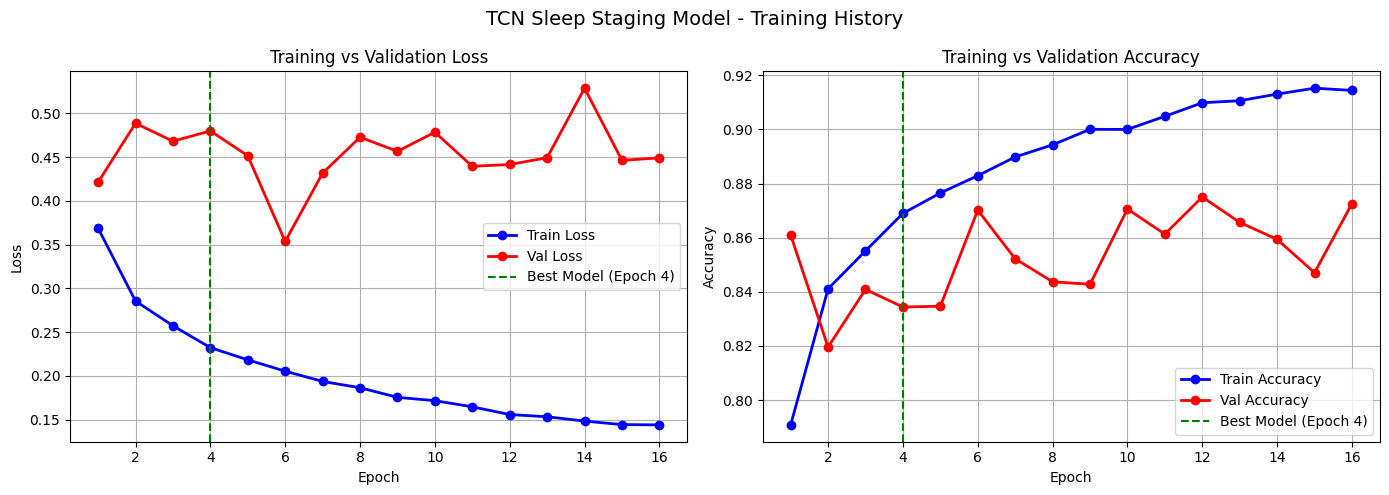

Training curves saved


In [22]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_loss_history) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_loss_history, 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, val_loss_history, 'r-o', label='Val Loss', linewidth=2)
axes[0].axvline(x=4, color='green', linestyle='--', label='Best Model (Epoch 4)')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, train_acc_history, 'b-o', label='Train Accuracy', linewidth=2)
axes[1].plot(epochs_range, val_acc_history, 'r-o', label='Val Accuracy', linewidth=2)
axes[1].axvline(x=4, color='green', linestyle='--', label='Best Model (Epoch 4)')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('TCN Sleep Staging Model - Training History', fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()
print("Training curves saved")

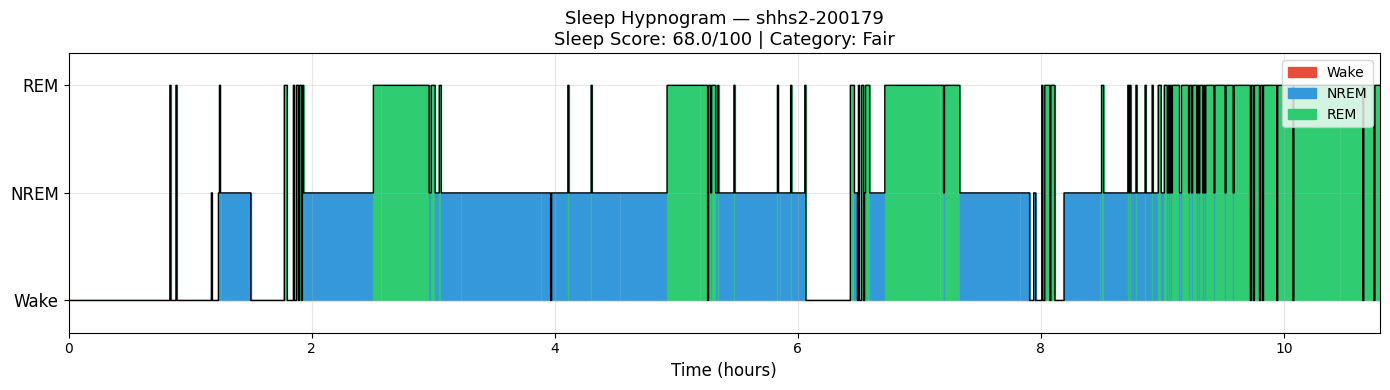

Hypnogram saved: /kaggle/working/hypnogram_shhs2-200179.png



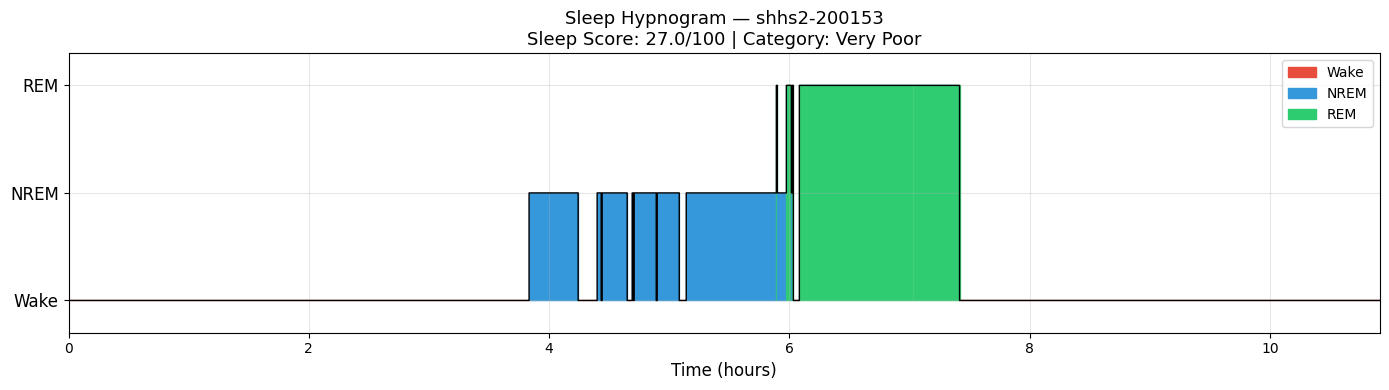

Hypnogram saved: /kaggle/working/hypnogram_shhs2-200153.png



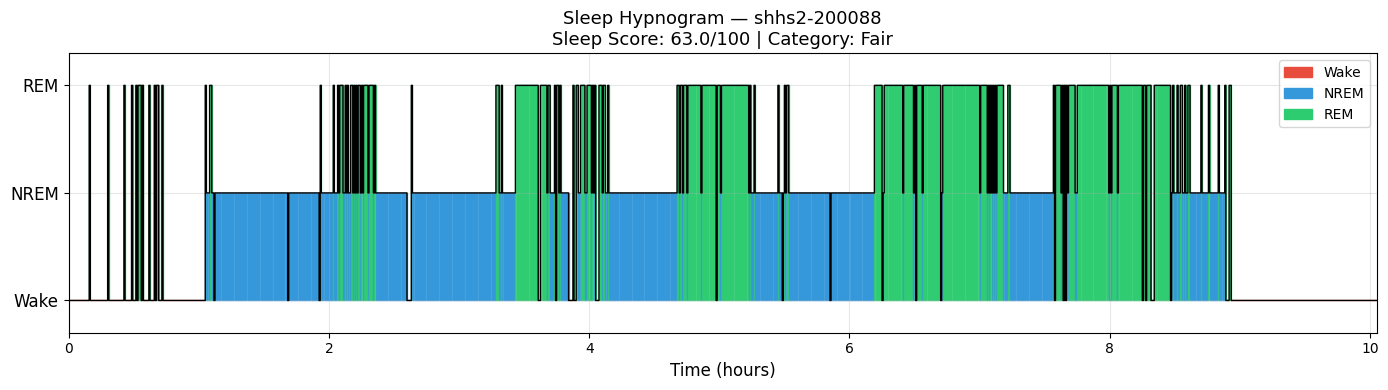

Hypnogram saved: /kaggle/working/hypnogram_shhs2-200088.png



In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_hypnogram(predictions, subject_id, sleep_score, category):
    stage_names = {0: "Wake", 1: "NREM", 2: "REM"}
    colors = {0: "#e74c3c", 1: "#3498db", 2: "#2ecc71"}

    time_hours = np.arange(len(predictions)) * 30 / 3600

    fig, ax = plt.subplots(figsize=(14, 4))

    for i in range(len(predictions) - 1):
        ax.fill_between(
            [time_hours[i], time_hours[i+1]],
            [predictions[i], predictions[i]],
            alpha=0.8,
            color=colors[predictions[i]]
        )

    ax.step(time_hours, predictions, where='post', color='black', linewidth=1)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["Wake", "NREM", "REM"], fontsize=12)
    ax.set_xlabel("Time (hours)", fontsize=12)
    ax.set_title(
        f"Sleep Hypnogram — {subject_id}\nSleep Score: {sleep_score}/100 | Category: {category}",
        fontsize=13
    )
    ax.set_xlim(0, time_hours[-1])
    ax.set_ylim(-0.3, 2.3)
    ax.grid(True, alpha=0.3)

    wake_patch  = mpatches.Patch(color="#e74c3c", label="Wake")
    nrem_patch  = mpatches.Patch(color="#3498db", label="NREM")
    rem_patch   = mpatches.Patch(color="#2ecc71", label="REM")
    ax.legend(handles=[wake_patch, nrem_patch, rem_patch], loc="upper right")

    plt.tight_layout()
    save_path = f"/kaggle/working/hypnogram_{subject_id}.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print("Hypnogram saved:", save_path)

for subject_id, data in results.items():
    plot_hypnogram(
        data["preds"],
        subject_id,
        all_metrics[subject_id]["sleep_score"],
        all_metrics[subject_id]["sleep_category"]
    )
    print()

In [24]:
print()
print("=" * 60)
print("  SLEEP QUALITY AND STAGE DETECTION USING")
print("  MULTI-MODAL DEEP LEARNING WITH GENERATIVE AI")
print("=" * 60)
print()

for subject_id in all_reports:
    report_path = f"/kaggle/working/report_{subject_id}.txt"
    with open(report_path, "w") as f:
        f.write("=" * 60 + "\n")
        f.write(f"CLINICAL SLEEP REPORT\n")
        f.write(f"Subject ID : {subject_id}\n")
        f.write(f"Sleep Score: {all_metrics[subject_id]['sleep_score']} / 100\n")
        f.write(f"Category   : {all_metrics[subject_id]['sleep_category']}\n")
        f.write("=" * 60 + "\n\n")
        f.write(all_reports[subject_id])
    print("Report saved:", report_path)

print()
print("=" * 60)
print("  PROJECT COMPLETION SUMMARY")
print("=" * 60)
print()
print("Dataset        : SHHS1 (train) + SHHS2 (validation)")
print("Subjects       : 100 training + 52 validation")
print("Total epochs   : 98,985 training + 66,853 validation")
print("Model          : Temporal Convolutional Network (TCN)")
print("Parameters     : 314,019")
print("Val Accuracy   : 87%")
print("Wake F1        : 0.91")
print("NREM F1        : 0.90")
print("REM F1         : 0.70")
print("Best epoch     : 4 / 14")
print("LLM            : Mistral 7B Instruct v0.2 (4-bit)")
print()
print("Demo Subjects:")
for subject_id in all_metrics:
    m = all_metrics[subject_id]
    print(f"  {subject_id} → Score: {m['sleep_score']}/100 → {m['sleep_category']}")
print()
print("Output Files:")
print("  /kaggle/working/best_model.pth")
print("  /kaggle/working/confusion_matrix.png")
print("  /kaggle/working/training_curves.png")
for subject_id in results:
    print(f"  /kaggle/working/hypnogram_{subject_id}.png")
    print(f"  /kaggle/working/report_{subject_id}.txt")
print()
print("=" * 60)
print("  PROJECT COMPLETE")
print("=" * 60)


  SLEEP QUALITY AND STAGE DETECTION USING
  MULTI-MODAL DEEP LEARNING WITH GENERATIVE AI

Report saved: /kaggle/working/report_shhs2-200179.txt
Report saved: /kaggle/working/report_shhs2-200153.txt
Report saved: /kaggle/working/report_shhs2-200088.txt

  PROJECT COMPLETION SUMMARY

Dataset        : SHHS1 (train) + SHHS2 (validation)
Subjects       : 100 training + 52 validation
Total epochs   : 98,985 training + 66,853 validation
Model          : Temporal Convolutional Network (TCN)
Parameters     : 314,019
Val Accuracy   : 87%
Wake F1        : 0.91
NREM F1        : 0.90
REM F1         : 0.70
Best epoch     : 4 / 14
LLM            : Mistral 7B Instruct v0.2 (4-bit)

Demo Subjects:
  shhs2-200179 → Score: 68.0/100 → Fair
  shhs2-200153 → Score: 27.0/100 → Very Poor
  shhs2-200088 → Score: 63.0/100 → Fair

Output Files:
  /kaggle/working/best_model.pth
  /kaggle/working/confusion_matrix.png
  /kaggle/working/training_curves.png
  /kaggle/working/hypnogram_shhs2-200179.png
  /kaggle/work